In [1]:
from importlib import reload
import FuncGarchEstimatorsMat as est # Estimator
import FuncGarchSimulators as sim # Simulator
from cStoreRes import *
from scipy import stats
import pandas as pd
import numpy as np
import typing, collections
from mpl_toolkits.mplot3d import Axes3D  
from matplotlib import cm

from numba import jit, njit

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (24, 8)

cStoreRes V.1.1.1
FuncGarchEstimatorsMat V.1.1.3


This notebook serves as a documentation and discussion of the theoretical considerations in the paper *Functional GARCH models: The quasi-likelihood approach
and its applications* by Clément Cerovecki, Christian Francq, Siegfried Hörmann and Jean-Michel Zakoïan.

That is, let $(\Omega,\mathcal{F},(\mathcal{F}_t)_{t\in T},P)$ be a filtered probability space indexed by some additive semigroup $T$, let $S:\Omega\to E$ for some separable Banach space $E$ endowed by the Borel $\sigma$-algebra $\mathcal{E}$ and let $S_t:\Omega\times[0,1]\to\mathbb{R}^{[0,1]}$ be the intraday price with $X_i(u)=\log X_i(u)/X_i(u-\delta)$, for some $\delta>0$, the logarithmic returns. Write $H=L^2([0,1],\mathcal{F})$ be the Hilbert space of square-integrable $\mathcal{F}$-measurable maps endowed with the inner product $\langle\cdot,\cdot\rangle$. Additionally, let $L(H)$ denote the space of bounded linear operators on $H$ equipped with the operator norm $\|X\|=\sup\{\|X(x)\|:\|x\|\leq 1\}$.

Define $H^+=\{X\in H:X\geq 0 \text{ a.e.}\}$ with $H^+_*=\{X\in H:X> 0 \text{ a.e.}\}$ and let $K(H)$ be the space of kernel operators on $H$. One verifies that the direct sum $H^n=\bigoplus_{k=1}^nH$ inherets the hilbert geometry induced by the inner product so that $\langle x,y\rangle=\sum_{k\leq n}\langle x_k,y_k\rangle$ for any $x,y\in H^n$.

**Definition.** Let $(\eta_t)_{t\in T}$ be a random sequence in $H$ generating independent $\sigma$-fields. We call $(X_t)_{t\in T}$ a functional $\text{GARCH}(p,q)$ model if it is a stationary solution to the equation
$$
X_t(u)=\sigma_t\eta_t(\omega),\quad\sigma_t^2=\delta+\sum_{j=1}^pT_jX_t^2+\sum_{j=1}^qT'_j\sigma^2_{t-1}
$$
for $T,T'\in H$. we say that $(X_t)_{t\in T}$ is nonanticipative if there exists an $\mathcal{F}^{\infty}$-measurable map $\psi$ so that $\sigma_{t+1}=\psi(\eta_t,\eta_{t-1},...)$.

## Data preparation

We start with the data preparation. Indeed, the theoretic considerations in Cerovecki et al. assumes that $(X_j)_{j\in T'\subset\mathbb{Z}}$ are a countable sequence of curves, measurable with respect to the extended cylindrical $\sigma$-algebra on $[0,1]$, yet, we can approximate these series using high-frequency replacements $\tilde{X}_j:\Omega\times L'\to\mathbb{R}^{L'}$ where $L'=\bigcup_{j=1}^{2^n}\{j/2^n\}$ is a lattice over $[0,1]$. Indeed, when preparing the data, we need to transform the loaded information into this paradigm in order to do inference.

That is, using the `pandas.DataFrame(NDFrame, OpsMixin)` class object, define an object `data = pandas.DataFrame(**_)` and transform it into a `numpy.matrix`, mathematically denoted $\tilde{X}$ such that
$$
\tilde{X}=\begin{pmatrix}\tilde{X}_1(0)&\cdots&\tilde{X}_1(1)\\
\vdots&\ddots&\vdots\\
\tilde{X}_n(0)&\cdots&\tilde{X}_n(1)\end{pmatrix},\quad\tilde{X}\in\mathbb{R}^{n\times m}
$$
so that we have $n$ days, each composed of $m$ intraday observations. In the example below, we write a data object using the `pandas.(filepath_or_buffer: FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str], **_)` function, which is a $40\times 561$ object, with 561 days and 40 intraday observations, defined on a ten minute grid.

In [2]:
data = pd.read_csv('SP500.csv', parse_dates=True, index_col = 'TIME').resample('600S').last().dropna(axis = 1)
time_index = data.index[1:]
date_index = np.sort([pd.to_datetime(item, format = '%d/%m/%Y') for item in data.columns])
data.head()

,31/12/2015,04/01/2016,05/01/2016,06/01/2016,07/01/2016,08/01/2016,11/01/2016,12/01/2016,13/01/2016,14/01/2016,...,16/03/2018,19/03/2018,20/03/2018,21/03/2018,22/03/2018,23/03/2018,26/03/2018,27/03/2018,28/03/2018,29/03/2018
TIME,,,,,,,,,,,,,,,,,,,,,
2024-03-26 08:30:00,2045.75,1997.00,2007.75,1984.0,1955.0,1947.25,1922.25,1936.00,1942.75,1883.00,...,2759.00,2741.00,2720.50,2719.00,2690.25,2650.00,2636.50,2664.75,2605.00,2620.75
2024-03-26 08:40:00,2044.25,1995.25,2008.50,1985.0,1958.5,1946.50,1917.25,1937.75,1937.25,1884.50,...,2761.25,2737.00,2724.00,2716.75,2692.00,2643.50,2634.75,2657.00,2617.00,2613.00
2024-03-26 08:50:00,2045.00,1996.75,2004.00,1986.5,1956.5,1949.00,1915.50,1934.25,1935.50,1874.25,...,2760.75,2738.75,2720.25,2717.00,2686.25,2647.75,2634.00,2664.50,2619.25,2612.00
2024-03-26 09:00:00,2044.25,1992.50,2001.50,1985.5,1953.0,1938.50,1917.25,1929.25,1937.25,1876.50,...,2758.75,2736.00,2721.00,2721.25,2690.00,2649.00,2633.00,2663.50,2622.00,2611.00
2024-03-26 09:10:00,2043.25,1995.75,2003.25,1986.0,1958.5,1938.25,1914.25,1929.00,1930.75,1889.00,...,2762.25,2734.75,2719.00,2719.75,2695.00,2645.75,2630.75,2657.25,2610.50,2617.00


In [3]:
complete_index = []
for date in date_index:
    _date = str(date).split(' ')[0]
    for time in time_index:
        complete_index += [pd.to_datetime(_date + ' ' + str(time.time()))]

complete_index = np.sort(complete_index)

Next, to obey to the paradigm sketched above, we transform the data using `numpy`. Indeed, in case `data` follows a different geometry, then one needs to adjust accordingly in order to construct the object `mY`, which is defined as a `numpy.matrix` object with shape `(m, n)`, which is the transposed version of $\tilde{X}$.

In [4]:
mY = 100 * np.log(data[1:] / data[:-1].values).values
mY_id = 100 * np.log(data[1:] / data.iloc[0].values).values
print(f'Shape mY: {mY.shape}, mY_id: {mY_id.shape}')

Shape mY: (39, 561), mY_id: (39, 561)


Below, we graph the ten-minute returns, i.e. $\delta=10$, and the intraday returns $\hat{X}_j(u)=\log S_j(u)/S_j(0)$

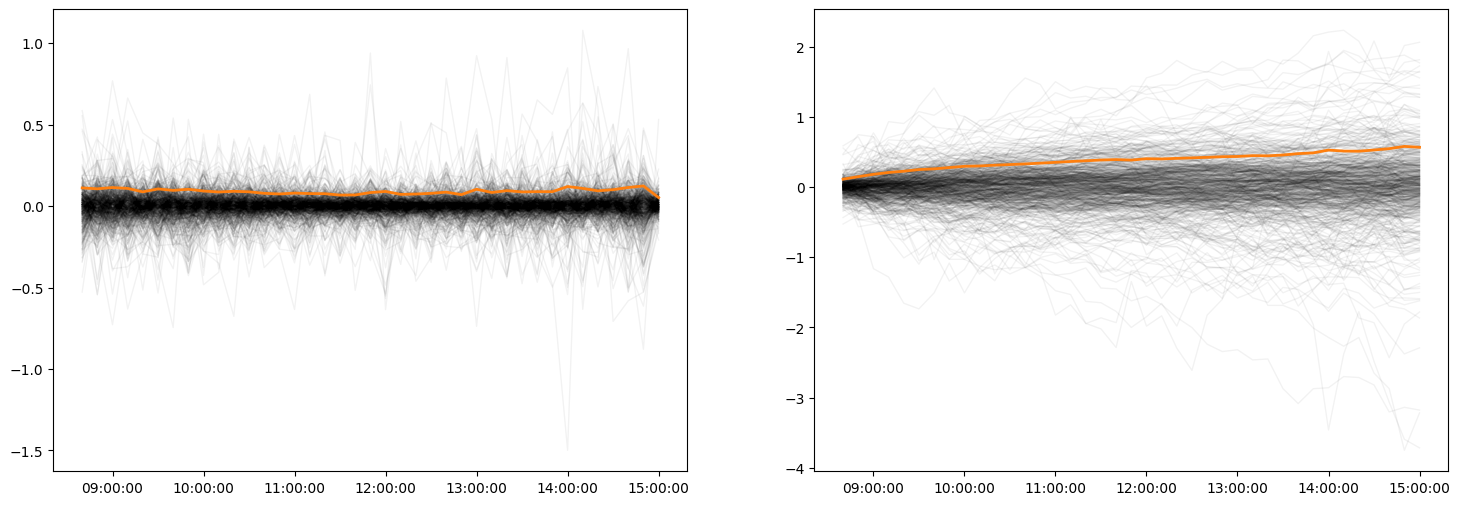

In [5]:
import matplotlib.dates as md
fig, axs = plt.subplots(1, 2, figsize = (18, 6))

axs[0].plot(time_index, mY, color = 'black', lw = 1, alpha = .05)
axs[0].plot(time_index, np.mean((mY[:, :] ** 2), axis = 1) ** .5, color = 'C1', lw = 2, alpha = 1)

axs[1].plot(time_index, mY_id[:, :], color = 'black', lw = 1, alpha = .05)
axs[1].plot(time_index, np.mean((mY_id[:, :] ** 2), axis = 1) ** .5, color = 'C1', lw = 2, alpha = 1)
# for ax in axs: ax.set_yscale('symlog')
for ax in axs:
    ax.xaxis.set_major_formatter(md.DateFormatter('%H:%M:%S'))
plt.show()

## Estimation of functional GARCH models

We now focus on the estimation procedure as discussed in Cerovecki et al., which is contructed using projections on dense subspaces $\mathcal{H}$. Consequently, we assume that there exists $M$ linearly independent baseline functions $(\varphi_j)_{j=1,...,M}\subset H^+$, a vector $\xi\in\mathbb{R}^M$ and matrices $A,B\in\mathbb{R}^{M\times M}$ so that
$$
\sigma_t^2=\sum_{k=1}^M\xi_k\varphi_k+\sum_{j=1}^p\sum_{k=1}^M\sum_{l=1}^MA_{k,l}^{(j)}\varphi_k\otimes\varphi_l X_t^2+\sum_{j=1}^q\sum_{k=1}^M\sum_{l=1}^MB_{k,l}^{(j)}\varphi_k\otimes\varphi_l \sigma^2_{t-1}
$$
which defines our parameter vector $\theta=\operatorname{vec}(\xi,A^{(1)},...,A^{(M)},B^{(1)},...,B^{(M)})$ in which we assume that $\theta\mapsto \sigma_t^2(\cdot,\theta)$ is injective, see any standard graduate textbook on mathematical inference theory for additional notes.

Next, we define the estimated volatility $\tilde{\sigma}_j(u)$ computed recursively using the above representation, minimising the loss objective
$$
Q_n(\theta)=n^{-1}\sum_{t=1}^n\sum_{j=1}^M\frac{\langle X_t^2,\varphi_j\rangle}{\langle \tilde{\sigma}_t^2,\varphi_j\rangle}+\log\langle \tilde{\sigma}_t^2,\varphi_j\rangle
$$
which is called the quasi-MLE.

## Implementation

In order to run the above estimation procedure, we can resort to the function `FuncGarchEstimators.main(**kwargs)`, which is a function which estimates $\theta$ for a given $M$ and a basis on which to project. That is, we initialise the method using a parameter diffuse initalisation
```
grid_length = mY.shape[0]

M: int = 4
config: dict = {
        'x0'        :   [np.random.uniform(0,1) for i in range(M + 2 * (M ** 2))],
        'bounds'    :   [(None, None)] * (M + 2 * (M ** 2)),
        'method'    :   'Nelder-Mead',
    }

# This estimation is done using the Bernstein polynomials
vThetaHat = est.main(
            mY, 
            grid_length =   grid_length, 
            M           =   M, 
            sigma2Int   =   np.ones(grid_length) * np.std(mY), 
            **config
    )
```
To be an easy to use model, we implemented a standard representation for $\varphi_k$, defined to be the Bernstein polynomials $\varphi_k(u)=\frac{\Gamma(M - 1)}{\Gamma(M - k)\Gamma(k - 1)}u^{k}(1-u)^{M-k}$ for $u\in[0,1]$. These are already used as a standard basis in `FuncGarchEstimators.main(**kwargs)` and so do not need to specified. In the example below, we project on $M=6$ Bernstein basis functions to show the flexibility of the functional basis. However, there is a computational and probabilistic limitation in the way one would specify the dimension of $\mathcal{H}=\text{span}\{\varphi_1,...,\varphi_k\}$, which ideally should be done in a seminonparametric manner.

Additionally, the `FuncGarchEstimators.main(**kwargs)` is endowed with a standard loss function, choosen to be the quadratic loss 
$$\Psi_n(\theta)=\frac{1}{n}\sum_{j=1}^n\sum_{k\in\mathbb{N}\cap[1,M]}(\langle y_t^2(\omega), \varphi_k\rangle-\langle\sigma_t^2(\omega), \varphi_k\rangle)^2.$$
Yet, if one wants to experiment using a custom objective function, then this can be added to the `FuncGarchEstimators.main(**kwargs)` using the argument `FuncGarchEstimators.main(LossFunc = My_Custom_Loss_Func, **kwargs)`. To be applicable, the custom loss function must take as arguments `(mY: typing.Any, vsigma2: typing.Any, M: int, gridH: typing.Any)` and must return a float value representing the loss, an example for the quasi-MLE loss is sketched below. In case one wants to see the convergence results, then the `main` function has a parameter `print_convergence` which can be set to `True` to print convergence results.

In [6]:
@jit(nopython = True)
def LossFunc(mY: typing.Any, vsigma2: typing.Any, M: int, gridH: typing.Any) -> ...: # We supply the loss function with the required inputs, which are used in the est.main method
    _final: float = .0
    for k in range(1, M + 1):
        oclb = est.BernsteinBasis(gridH, M = M, k = k)
        _final += np.mean(mY ** 2 / vsigma2) + np.mean(np.log(vsigma2 * oclb))
        
    return _final

In [7]:
grid_length = mY.shape[0]

M: int = 4
config: dict = {
        'x0'        :   [np.random.uniform(0,1) for i in range(M + 2 * (M ** 2))],
        'bounds'    :   [(None, None)] * (M + 2 * (M ** 2)),
        'method'    :   'Nelder-Mead',
    }

# This estimation is done using the Bernstein polynomials
vThetaHat = est.main(
            mY, 
            grid_length =   grid_length, 
            M           =   M, 
            sigma2Int   =   np.ones(grid_length) * np.std(mY), 
            LossFunc    =   LossFunc, 
            **config
    )

For applicational considerations, the `main` function returns a `UtilContainer` object, which is defined as a class object initialised with the attributes of a `scipy.~.OptimizeResult` object. Indeed, to access the estimated coefficients, one can simply call the `self.x` in the `UtilContainer` as this is inhereted from the `OptimizeResult` object.

Now for purposes of plotting, we added a function in the `FuncGarchEstimatorsMat.py` file called `CUDAkernelFilter` which returns the estimated volatility based on the estimated parameters. Indeed, if the parameters are estimated on a custom function for the volatility, then this exact speficiation must be used in the `CUDAkernelFilter` too.

In [8]:
coefs = vThetaHat.x
mSigma_hat = est.CUDAkernelFilter(mY, grid_length, coefs, M, np.ones(grid_length) * np.std(mY))
print(coefs)

[ 3.65327617e-03 -2.53913910e-03 -9.70850955e-04  1.76616714e-03
  5.51370323e-01  8.53343398e-01  9.58676362e-01 -4.32257513e-01
  3.85876921e-01 -1.45179150e-01  2.67227351e-02  9.51094358e-01
  5.33187769e-01  3.90021975e-01  8.12016375e-01 -4.74087849e-02
  1.51491844e-01  6.70146359e-01  6.10689745e-01  4.50305096e-01
  8.15984901e-01  5.84466736e-01  9.38762823e-03  2.59086964e-01
  9.09182166e-01  6.95942177e-01  1.27073605e+00  1.48704622e-01
  2.15632685e-01  2.29531221e-01  5.61618722e-01  1.11407677e+00
  2.52655626e-01  3.25402867e-01  7.11231028e-01  4.15681813e-01]


One should be carefull when choosing the number of basis functions, as for example $M=6$ is almost an overfitted curve, as demonstrated below. This, trivially, additionally induces extra computational complexity.

In [9]:
grid_length = mY.shape[0]

M: int = 6
config: dict = {
        'x0'        :   [np.random.uniform(0,1) for i in range(M + 2 * (M ** 2))],
        'bounds'    :   [(None, None)] * (M + 2 * (M ** 2)),
        'method'    :   'Nelder-Mead',
    }

# This estimation is done using the Bernstein polynomials
vThetaHat_overfitted = est.main(
            mY, 
            grid_length =   grid_length, 
            M           =   M, 
            sigma2Int   =   np.ones(grid_length) * np.std(mY), 
            LossFunc    =   LossFunc, 
            **config
    )

In [10]:
coefs_overfitted = vThetaHat_overfitted.x
mSigma_hat_overfitted = est.CUDAkernelFilter(mY, grid_length, coefs_overfitted, M, np.ones(grid_length) * np.std(mY))
print(coefs_overfitted)

[ 3.55809511e-03  2.18263343e-03  9.54058739e-04 -3.85716842e-03
  2.77806512e-03 -3.22836652e-04  2.50457099e-01  1.26235724e-02
 -1.08298843e+00  1.11416314e-01  7.45890602e-02  6.84640592e-01
  1.50833949e-01  3.43629361e-01  1.86977540e-01  5.31048999e-01
  9.09499151e-01 -7.23979895e-02  8.07329297e-01  5.56121212e-01
  1.41242036e-02  6.22262968e-01  3.51364910e-01  8.66350423e-02
  5.31642838e-02  1.73088190e-01  4.71490066e-01  1.07080906e+00
  9.50073702e-01  1.00667719e+00  1.08220508e+00  1.42784648e-01
  2.85051334e-01  2.24337746e-01  2.82138358e-01  2.68705507e-01
  5.12649454e-01  5.57945645e-01  9.88101837e-01  1.02262058e-01
  8.09604221e-01 -3.61004244e-01  1.63643919e-02  1.26100099e-01
  1.14422448e-01  2.44647519e-02  1.30141927e-04  1.35027585e+00
  1.60030766e+00  1.39143450e-01  1.60201917e-01  7.67884684e-01
  1.13752666e+00  1.15805269e+00  6.92121581e-02  1.35610484e-01
  2.07159113e-01  1.19191433e+00  4.80531791e-01  4.86002131e-02
  1.25195654e-01  1.18324

Let us define a simple function to generate the functional estimates similar to Cerovecki et al. To do so, we first define a decorator which adjusts the figure size to suit the graph we are plotting.

In [11]:
import matplotlib.dates as mdates

def GenGraph(
        mY:             typing.Any | None,
        mSigma_hat:     typing.Any | None,
        config:         dict | None = {},
        time_index:     list | None = time_index,
        date_index:     list | None = date_index,
        complete_index: list | None = complete_index) -> plt.plot:
    if config: exec(config.get('figsize'))
    linestyles = ['-','--','dotted']
    num_plots = len(mSigma_hat) + 1
    plt.title('Graphical representation')
    plt.subplot(num_plots, 1, 1)
    mY_emp = np.sqrt(np.mean((mY[:, :]) ** 2, axis = 1))
    plt.plot(time_index, mY_emp, color = 'C0', alpha = 1, lw = 1, label = 'Empirical volatility')
    for (mS, mS_name), ls in zip(mSigma_hat, linestyles):
        plt.plot(time_index, np.sqrt(np.mean(mS[:, :], axis = 1)), color = 'black', lw = 1, alpha = 1, label = mS_name, ls = ls)
    
    plt.gcf().autofmt_xdate()
    myFmt = mdates.DateFormatter('%H:%M')
    plt.gca().xaxis.set_major_formatter(myFmt)
    plt.xlabel('Intraday times $u\in[0,1]$')
    plt.ylabel('Estimated functional volatilities $\hat{\sigma}_i(u)$')
    plt.legend()

    idxs = 4
    for idx, ((mS, mS_name), ls) in enumerate(zip(mSigma_hat, linestyles)):
        plt.subplot(num_plots, 3, idxs)
        plt.plot(complete_index, mY.T.flatten() / np.sqrt(mS.T.flatten()), color = 'black', lw = .2, alpha = 1, label = mS_name, ls = ls)
        plt.xlabel('Intraday times $u\in[0,n]$')
        plt.ylabel('Normalised estimated returns\n $\hat{\epsilon}_i(u)=y_i(u)/\hat{\sigma}_i(u)$')
        plt.legend()

        plt.subplot(num_plots, 3, idxs + 1)
        num_bins = 100
        resid = mY.T.flatten() / np.sqrt(mS.T.flatten())
        plt.hist(resid, bins=num_bins, alpha=0.5, density = False, color='white', ec = 'black')

        y = np.linspace(min(resid), max(resid), 1000)
        bin_width = (max(resid) - min(resid)) / num_bins
        plt.plot(y, stats.norm.pdf(y) * len(resid) * bin_width, label = mS_name)
 
        # plt.hist(mY.flatten() / np.sqrt(mS.flatten()), color = 'black', lw = .5, alpha = 1, label = mS_name, ls = ls)
        plt.xlabel('Estimated innovations')
        plt.ylabel('Histogram to $\hat{\epsilon}_i(u)$')
        plt.legend()

        plt.subplot(num_plots, 3, idxs + 2)
        QQ = stats.probplot(resid)
        X = QQ[0][0]
        Y = QQ[1][0] * X + QQ[1][1]
        plt.scatter(QQ[0][0], QQ[0][1], s = 5, label = 'Theoretic-Empirical quantile-quantile relation')
        plt.plot(X, Y, lw = 1, color = 'black', label = 'Fitted QQ-relation')
        plt.legend()
        idxs += 3
    plt.tight_layout()
    plt.show()

def GenGraph3D(
        mY:             typing.Any | None,
        mSigma_hat:     typing.Any | None,
        BUFFER:         int | None = 20,
        config:         dict | None = {}) -> plt.plot:
    ## Include readable axis label
    BUFFER: int = 20

    fig = plt.figure(figsize=(18, 12))
    # ax = fig.add_subplot(121, projection='3d')
    # X = np.arange(BUFFER, mY.shape[1] - BUFFER, 1)
    # Y = np.linspace(0, 1, mY.shape[0])
    # X, Y = np.meshgrid(X, Y)
    # Z = np.sqrt(mSigma_hat[:, BUFFER:-BUFFER])

    # ax.plot_surface(X, Y, Z, cmap=cm.Spectral)

    # ax.set_xlabel('$i\in\mathbb{Z}\cap[0,n]$')
    # ax.set_ylabel('$t\in[0,1]$')
    # ax.set_zlabel('$\sigma_i^2(t,\omega)=\alpha_i(t)+\beta_i(t)\sigma_{i-1}^2+\gamma_{i}(t)y_{i-1}^2$')

    ax = fig.add_subplot(111, projection='3d')
    X = np.arange(BUFFER, mY.shape[1] - BUFFER, 1)
    Y = np.arange(0, 1, 1 / mY.shape[0])[::-1]
    X, Y = np.meshgrid(X, Y)
    Z = np.sqrt(mSigma_hat[:, BUFFER:-BUFFER])

    ax.plot_surface(X, Y, Z, cmap=cm.Spectral)
    ax.set(xticklabels=date_index, yticklabels=time_index)
    ax.set_xlabel('Date')
    ax.set_ylabel('Intraday time')
    ax.set_zlabel('$\sigma_i^2(t,\omega)=\alpha_i(t)+\beta_i(t)\sigma_{i-1}^2+\gamma_{i}(t)y_{i-1}^2$')
    ax.view_init(elev=30, azim=-45)
    plt.tight_layout()
    plt.show()

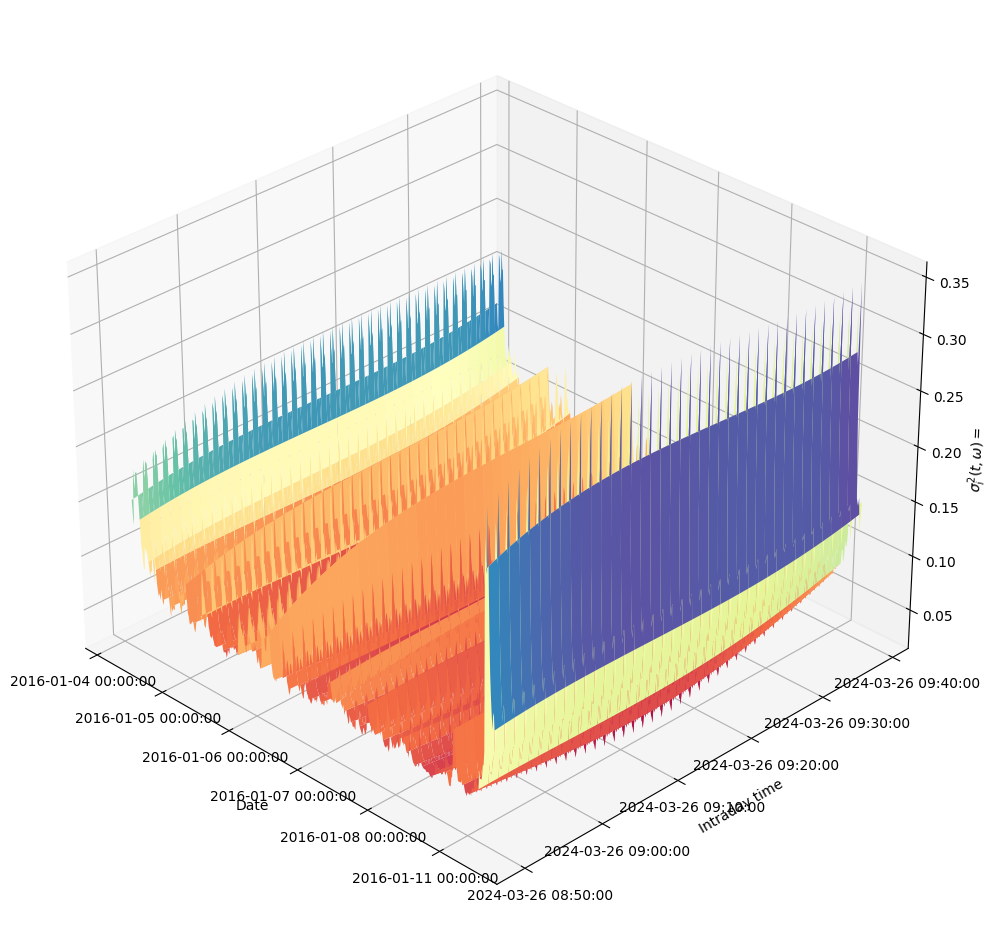

In [12]:
GenGraph3D(mY, mSigma_hat, BUFFER = 0)

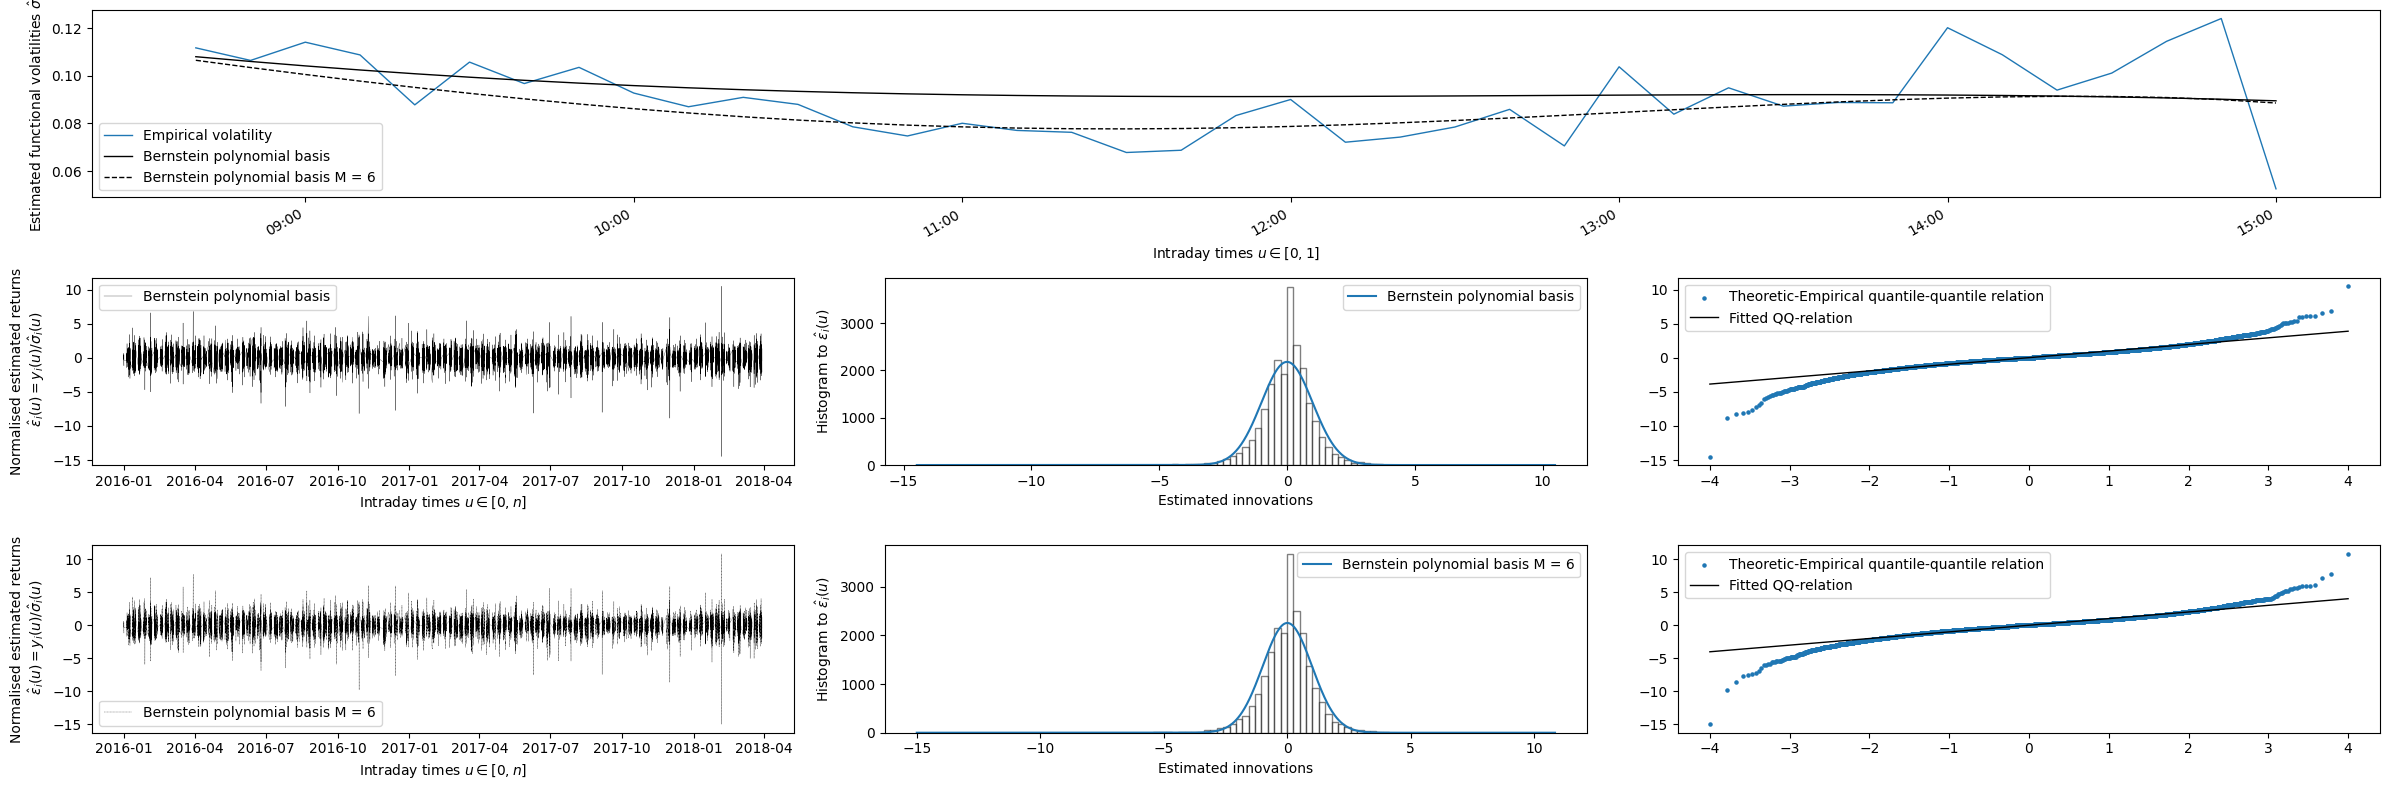

In [13]:
GenGraph(mY, [(mSigma_hat, 'Bernstein polynomial basis'), (mSigma_hat_overfitted, 'Bernstein polynomial basis M = 6')])

In [14]:
M = 4
coefs_delta: list = coefs[:M]
coefs_alpha: list = coefs[M: M + M ** 2]
coefs_beta : list = coefs[M + M ** 2:]

In [15]:
def functional_operator(t: typing.Any, coefs: list, M: int, _ret: typing.Any):
    _final = _ret
    input_grid = t.reshape((len(t),1))
    indexer: int = 0
    for k in range(1, M + 1):
        for l in range(1, M + 1):
            coef = coefs[indexer]
            _final = _final + coef * est.BernsteinBasis(input_grid, M, k) @ est.BernsteinBasis(input_grid, M, l).T
            indexer = indexer + 1
    return _final

To get a feel for how the operators $\alpha$ and $\beta$ act on the volatility and squared returns, we can apply them to an $n\times n$ matrix $A$ with $A_{i,j}=1$, which is shown below using a heatmap.

In [28]:
xsize = 51
M = 4

grid_args: dict = {
    't'     :   np.linspace(0, 1, xsize),
    'M'     :   M,
    '_ret'  :   np.zeros((xsize, xsize))
}

alpha_grid = est.functional_operator(coefs = list(coefs_alpha), **grid_args)
beta_grid  = est.functional_operator(coefs = list(coefs_beta),  **grid_args)

M = 6

grid_args: dict = {
    't'     :   np.linspace(0, 1, xsize),
    'M'     :   M,
    '_ret'  :   np.zeros((xsize, xsize))
}

alpha_grid_overfitted = est.functional_operator(coefs = list(coefs_overfitted[M: M +  M ** 2]), **grid_args)
beta_grid_overfitted  = est.functional_operator(coefs = list(coefs_overfitted[M + M ** 2 : ]),  **grid_args)

In [29]:
def GenGrid(_): 
    _df = pd.DataFrame(_[::-1], index = [round(item, 2) for item in np.linspace(0, 1, len(_))[::-1]])
    _df.columns = list([round(item, 2) for item in np.linspace(0, 1, len(_))])
    return _df

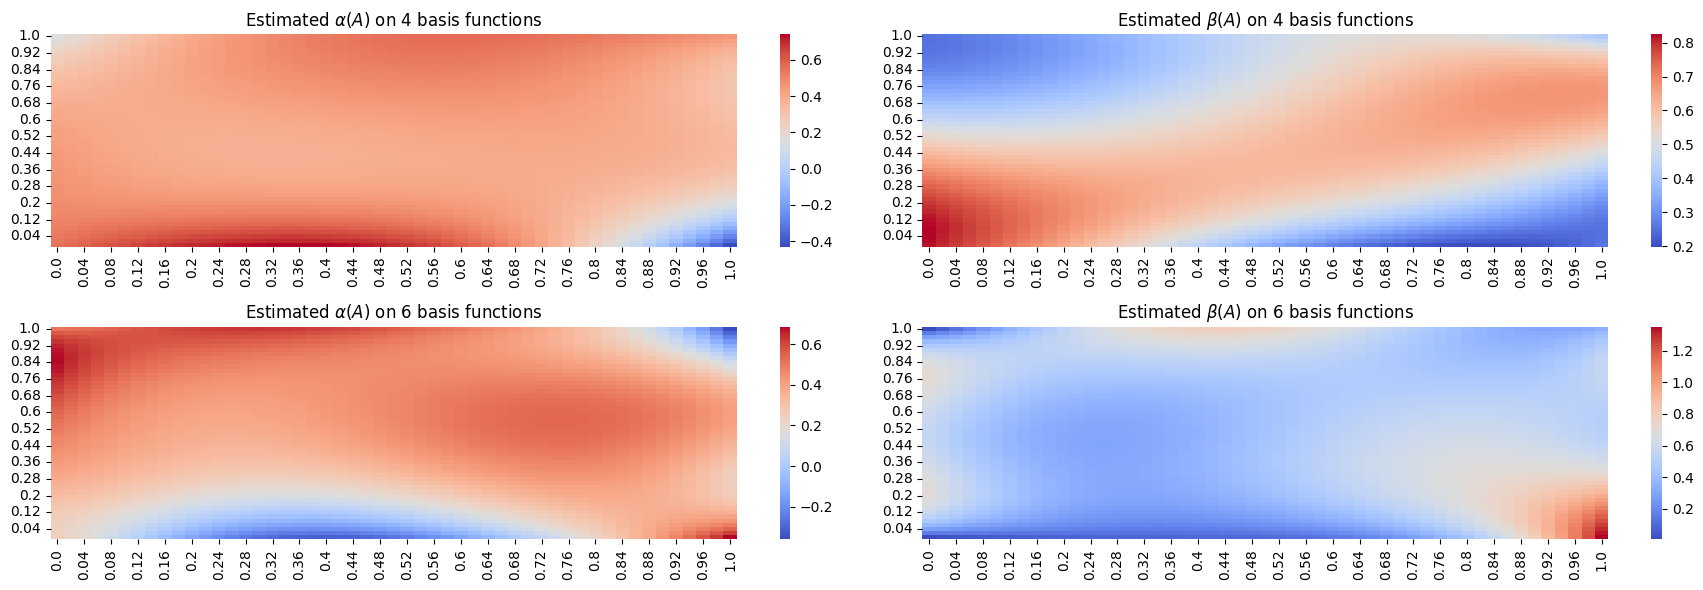

In [31]:
import seaborn as sns
fig, ax =plt.subplots(2,2, figsize = (18, 6))

ax[0,0].set_title(r'Estimated $\alpha(A)$ on 4 basis functions')
ax[0,1].set_title(r'Estimated $\beta(A)$ on 4 basis functions')
ax[1,0].set_title(r'Estimated $\alpha(A)$ on 6 basis functions')
ax[1,1].set_title(r'Estimated $\beta(A)$ on 6 basis functions')

sns.heatmap(GenGrid(alpha_grid), ax=ax[0,0], cmap = sns.color_palette("coolwarm", as_cmap=True))
sns.heatmap(GenGrid(beta_grid), ax=ax[0,1], cmap = sns.color_palette("coolwarm", as_cmap=True))
sns.heatmap(GenGrid(alpha_grid_overfitted), ax=ax[1,0], cmap = sns.color_palette("coolwarm", as_cmap=True))
sns.heatmap(GenGrid(beta_grid_overfitted), ax=ax[1,1], cmap = sns.color_palette("coolwarm", as_cmap=True))

plt.tight_layout()
plt.show()

Similar to a custom loss objective, it is also possible to project onto a different functional basis. As an example, we project to the 3-dimensional basis space $\mathcal{H}=\text{span}\{1,u^2,u(1-u)\}$. It is not hard too see that there exists an isomorphism from $\mathcal{H}$ onto the unit basis of $\mathcal{P}_2$, the space spanned by polynomials $p$ with order $k=0,1,2$. Indeed, the loss function is still projected on the Bernstein polynomial basis, and so to adjust to our new setting, we define the `SemiLossFunc` map to specifically set the oracle basis to the newly defined basis functions.

In [32]:
# @jit(nopython = True)
def SemiBasis(u: typing.Any, M: int, k: int):
    r"""
    The basis functions on which to project, currently set to Bernstein polynomials for k = 1,...,M and $\varphi_k^M(u)=_{M}C_ku^{k-1}(1-u)^{M-k}$
    """

    if k == 1: _ret: float | typing.Any = 1
    if k == 2: _ret: float | typing.Any = u ** 2 - .5
    if k == 3: _ret: float | typing.Any = u ** 2 - u + 5/6
    # if v <= 0: _ret: float | typing.Any = _mul * (1 - u) ** (n)
    return _ret

# @jit(nopython = True)
def SemiLossFunc(mY: typing.Any, vsigma2: typing.Any, M: int, gridH: typing.Any) -> ...:
    _final: float = .0
    for k in range(1, M + 1):
        oclb = SemiBasis(gridH, M = M, k = k)
        _final += np.mean(((mY ** 2 - vsigma2) * oclb) ** 2)

    return _final

In [33]:
M: int = 3
config: dict = {
        'x0'        :   [np.random.uniform(-1,1) for i in range(M + 2 * (M ** 2))],
        'bounds'    :   [(None, None)] * (M + 2 * (M ** 2)),
        'method'    :   'Nelder-Mead', # Sequential least squares programming,
    }

# This estimation is done using the Bernstein polynomials
vThetaHatSemi = est.main(mY, grid_length = grid_length, M = M, sigma2Int=np.ones(grid_length) * np.std(mY), LossFunc = SemiLossFunc, **config)

In [34]:
coefsSemi = vThetaHatSemi.x
mSigma_hatSemi = est.CUDAkernelFilter(mY, grid_length, coefsSemi, M, np.ones(grid_length) * np.std(mY))

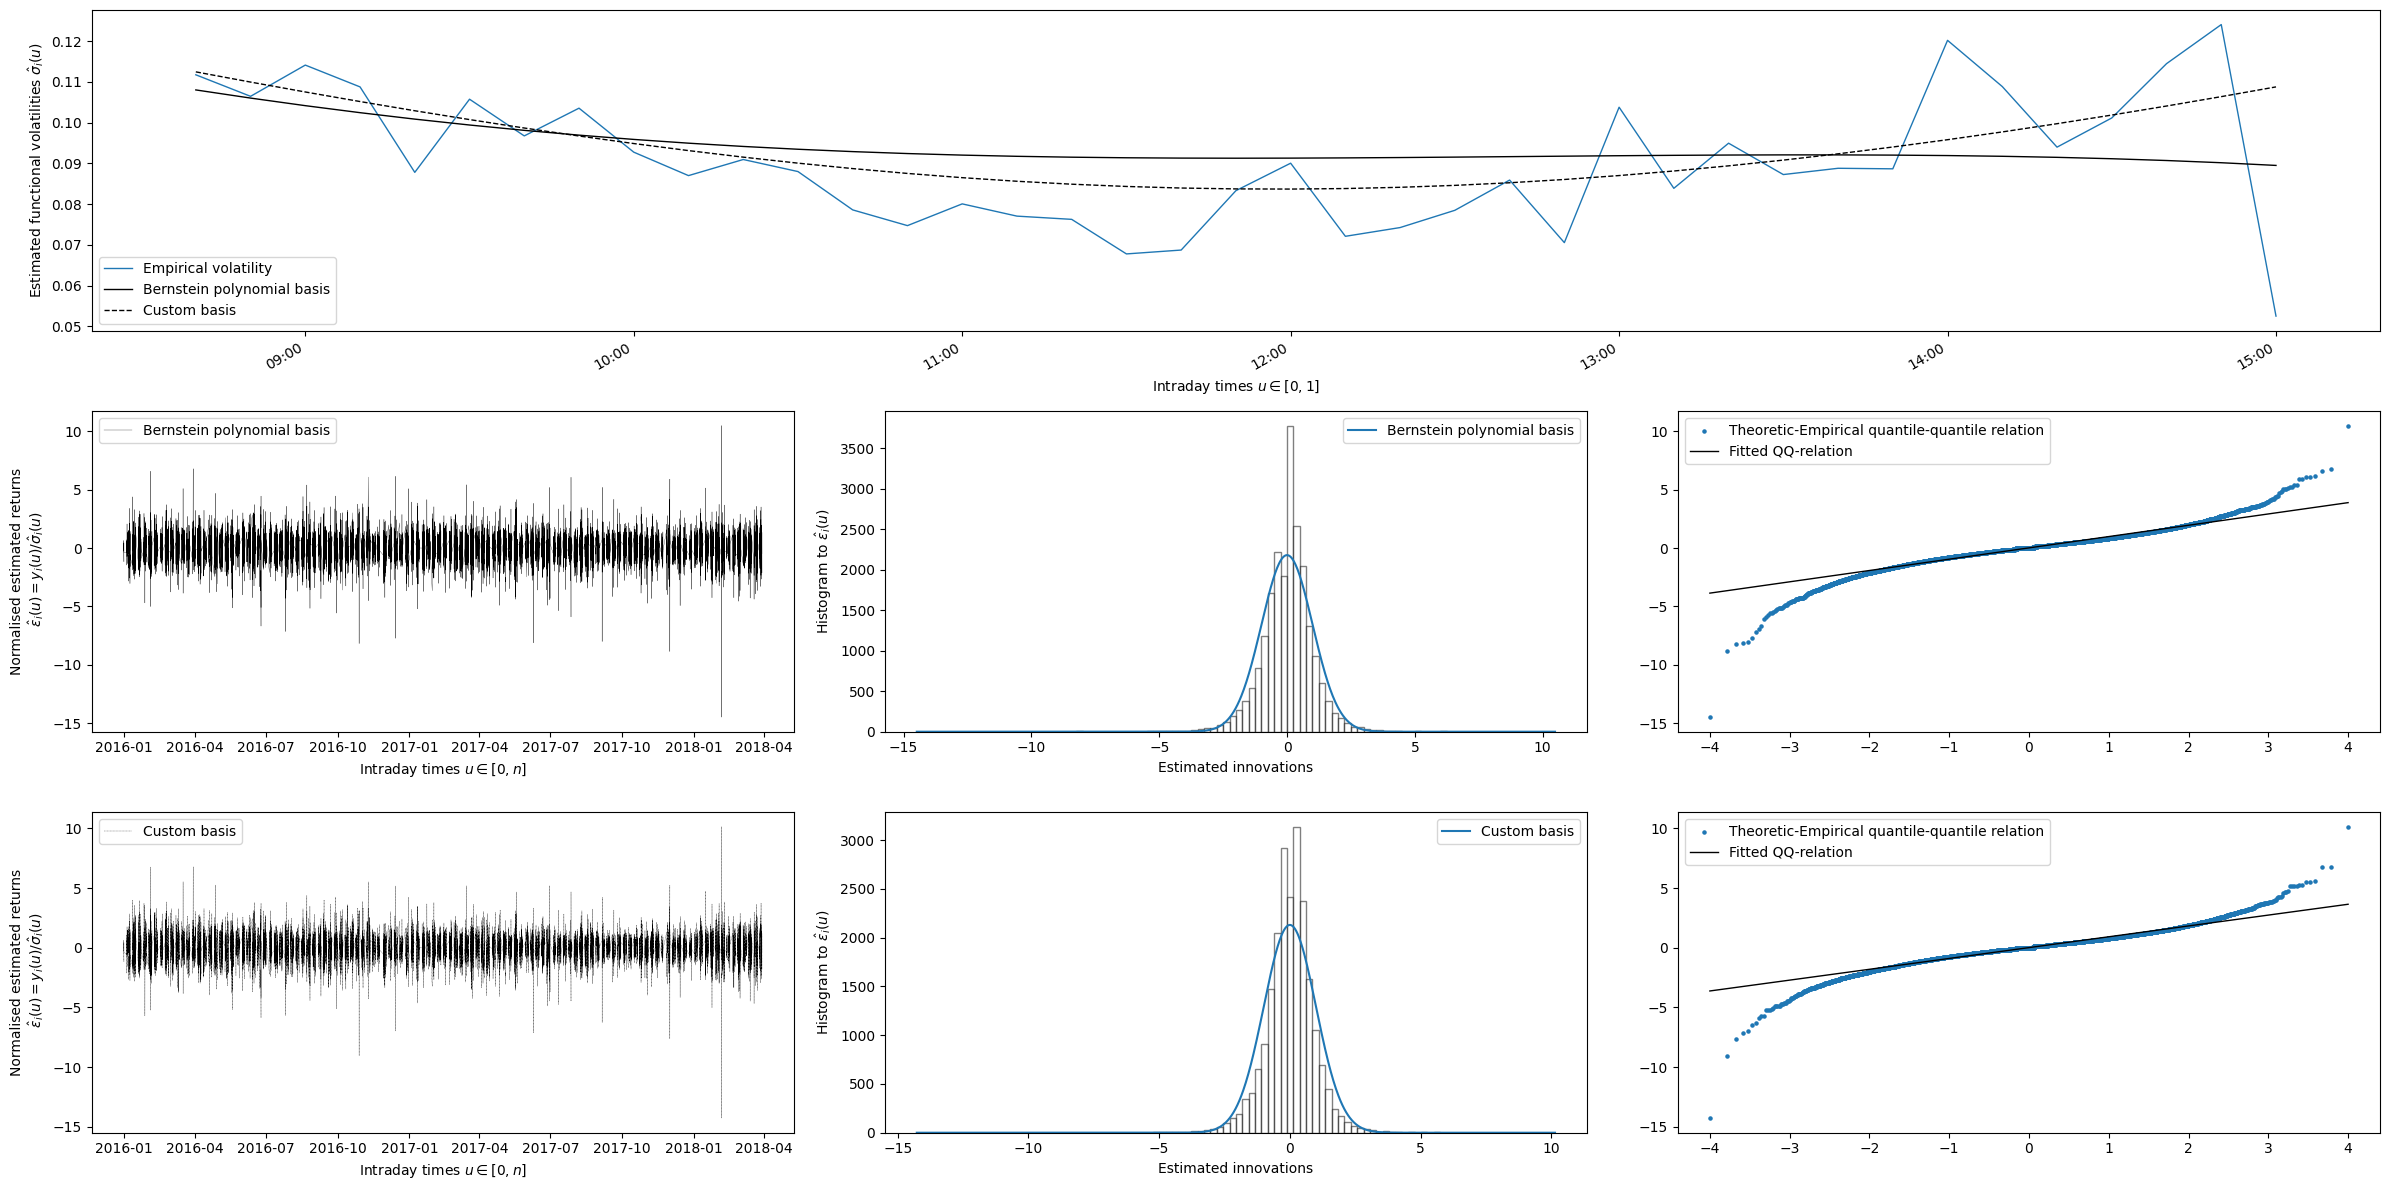

In [35]:
GenGraph(mY, [(mSigma_hat, 'Bernstein polynomial basis'), (mSigma_hatSemi, 'Custom basis')], config = {'figsize' : "plt.rcParams['figure.figsize'] = (24, 12)"})

In [47]:
xsize = 51
M = 3

grid_args: dict = {
    't'     :   np.linspace(0, 1, xsize),
    'M'     :   M,
    '_ret'  :   np.zeros((xsize, xsize))
}

alpha_grid_cb = est.functional_operator(coefs = list(coefsSemi[M: M + M ** 2]), **grid_args)
beta_grid_cb  = est.functional_operator(coefs = list(coefsSemi[M + M ** 2:]),  **grid_args)

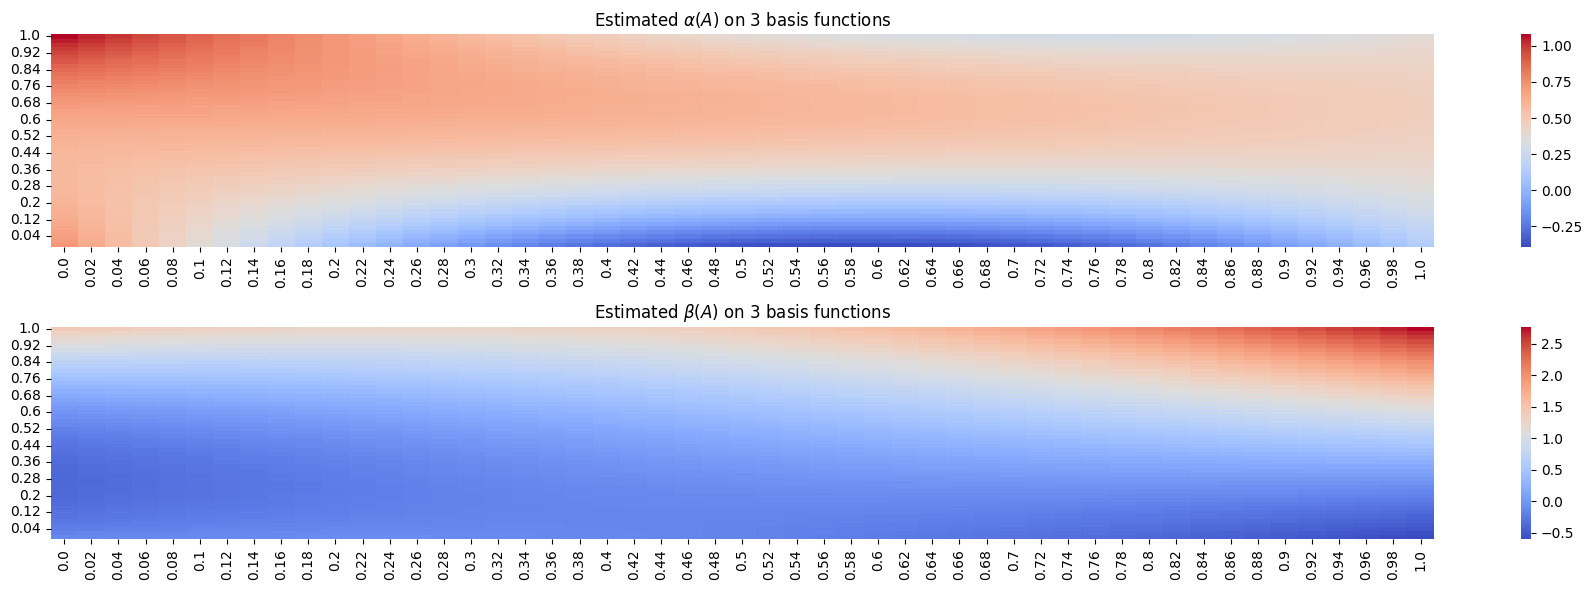

In [48]:
import seaborn as sns
fig, ax =plt.subplots(2, 1, figsize = (18, 6))

ax[0].set_title(r'Estimated $\alpha(A)$ on 3 basis functions')
ax[1].set_title(r'Estimated $\beta(A)$ on 3 basis functions')

sns.heatmap(GenGrid(alpha_grid_cb), ax=ax[0], cmap = sns.color_palette("coolwarm", as_cmap=True))
sns.heatmap(GenGrid(beta_grid_cb), ax=ax[1], cmap = sns.color_palette("coolwarm", as_cmap=True))

plt.tight_layout()
plt.show()

We test for normality with the obtained volatility surface

In [36]:
from scipy import stats
def GaussianTest(resid: typing.Any | None, test: object | None = stats.normaltest, **kwargs) -> typing.Any | None:
    if test == stats.normaltest: return test(resid)
    else: raise NotImplementedError()

In [37]:
BUFFER: int = 20
resid: np.array = (mY[:, BUFFER:-BUFFER] / np.sqrt(mSigma_hatSemi[:, BUFFER:-BUFFER])).flatten()
resid = [item for item in resid if not np.isnan(item)]

In [38]:
print(GaussianTest(resid = resid))

NormaltestResult(statistic=3588.3307726044554, pvalue=0.0)


The code below can be used to generate a dynamic graph that the user can interact with using his or her mouse.

In [28]:
# import plotly.graph_objects as go
# import pandas as pd
# import numpy as np
# # Read data from a csv

# X = np.arange(0, 40, 1)
# Y = np.arange(0, 1, 1 / 370)
# X, Y = np.meshgrid(X, Y)
# Z = mSigma_hatSemi[:, 10:]

# fig = go.Figure(go.Surface(
#     contours = {
#         "x": {"show": True, "start": 1.5, "end": 2, "size": 0.04, "color":"white"},
#         "z": {"show": True, "start": 1.5, "end": 2, "size": 0.1}
#     },
#     x = X,
#     y = Y,
#     z = Z))

# fig.update_layout(
#         scene = {
#             "xaxis": {"nticks": 20},
#             "zaxis": {"nticks": 8},
#             'camera_eye': {"x": 0, "y": -1, "z": 1},
#             "aspectratio": {"x": 1, "y": 1, "z": .6},
#             "xaxis_title":'$i\in\mathbb{Z}\cap[0,n]$',
#             "yaxis_title":'$t\in[0,1]$',
#             "zaxis_title":r'$\sigma_i^2(t,\omega)=\alpha_i(t)+\beta_i(t)\sigma_{i-1}^2+\gamma_{i}(t)y_{i-1}^2$'
#         })

# fig.show()

## Simulation

For research purposes, it is also possible to simulate `mY` using any functional representation one would like. Below, we give an example using the setting of Alexander Aue, Lahos Horvath and Daniel F. Pellatt, who define $\delta_i(s,t)=0.01$, and $\alpha_i(s,t)=\beta_i(s,t)=12t(1-t)s(1-s)$. To do so, we need to specify the appropriate model.

In [39]:
@jit(nopython = True)
def AUE_alpha(u: typing.Any, M: int, k: int):
    return u * (1 - u)

@jit(nopython = True)
def AUE_delta(coefs: list, t: float | typing.Any, M: int, _ret: typing.Any = .0):
    return 0.01 * np.ones(_ret.shape)

@jit(nopython = True)
def AUE_functional_representation(t: typing.Any, coefs: list, M: int, _ret: typing.Any):
    """
    This is an example for the alpha and beta coefficients, which is in geometry identical to the ones provided in the FuncGarchEstimatorsMat file
    """
    _final = _ret
    input_grid = t.reshape((len(t),1))
    indexer: int = 0
    for k in range(1, M + 1):
        for l in range(1, M + 1):
            coef = coefs[indexer]
            _final = _final + coef * AUE_alpha(input_grid, M, k) @ AUE_alpha(input_grid, M, l).T
            indexer = indexer + 1
    return _final

In [40]:
M: int = 1
config: dict = {
        'geometry'      : (285, 1200),
        'coefs'         : [12, 12, 12]
    }

In [41]:
mY, vsigma2M = sim.simulate(delta = AUE_delta, functional_operator = AUE_functional_representation, M = M, **config)

In [42]:
# @jit(nopython = True)
def AUE_basis(u: typing.Any, M: int, k: int):

    _ret: float | typing.Any = np.sqrt(30) * u * (1 - u)
    return _ret

# @jit(nopython = True)
def AUE_delta_est(coefs: list, t: float | typing.Any, M: int, _ret: typing.Any = .0):
    return coefs[0] * np.sqrt(30) * t * (1 - t)

# @jit(nopython = True)
def QuadraticLoss(mY: typing.Any, vsigma2: typing.Any, M: int, gridH: typing.Any) -> ...:
    _final: float = .0
    for k in range(1, M + 1):
        oclb = AUE_basis(gridH, M = M, k = k)
        _final += np.mean(((mY ** 2 - vsigma2) * oclb) ** 2)

    return _final

def LossFunc(mY: typing.Any, vsigma2: typing.Any, M: int, gridH: typing.Any) -> ...: # We supply the loss function with the required inputs, which are used in the est.main method
    _final: float = .0
    for k in range(1, M + 1):
        oclb = AUE_basis(gridH, M = M, k = k)
        _final += np.mean(mY ** 2 / vsigma2) + np.mean(np.log(vsigma2 * oclb))
        
    return _final

In [43]:
grid_length = mY.shape[0]

M: int = 1
config: dict = {
        'x0'        :   [.1, .2, .3],
        'bounds'    :   [(0, 5), (-.99, .99), (-.99, .99)],
        'method'    :   'Nelder-Mead', # Sequential least squares programming,
    }

# This estimation is done using the Bernstein polynomials
vThetaHatAEU = est.main(mY, 
                         grid_length = grid_length, 
                         M = M,
                         sigma2Int = np.ones(grid_length) * np.std(mY), 
                         LossFunc = LossFunc, 
                         delta = AUE_delta_est,
                         functional_operator = AUE_functional_representation,
                         **config)

Optimization terminated successfully.
         Current function value: -2797.054515
         Iterations: 32
         Function evaluations: 62


In [44]:
print(vThetaHatAEU.x)

[0.06139831 0.22141453 0.32876144]


In [45]:
coefsAEU = vThetaHatAEU.x
mSigma_hatAEU = est.CUDAkernelFilter(mY, grid_length, coefsAEU, 1, np.ones(grid_length) * np.std(mY), delta = AUE_delta_est, functional_operator = AUE_functional_representation)

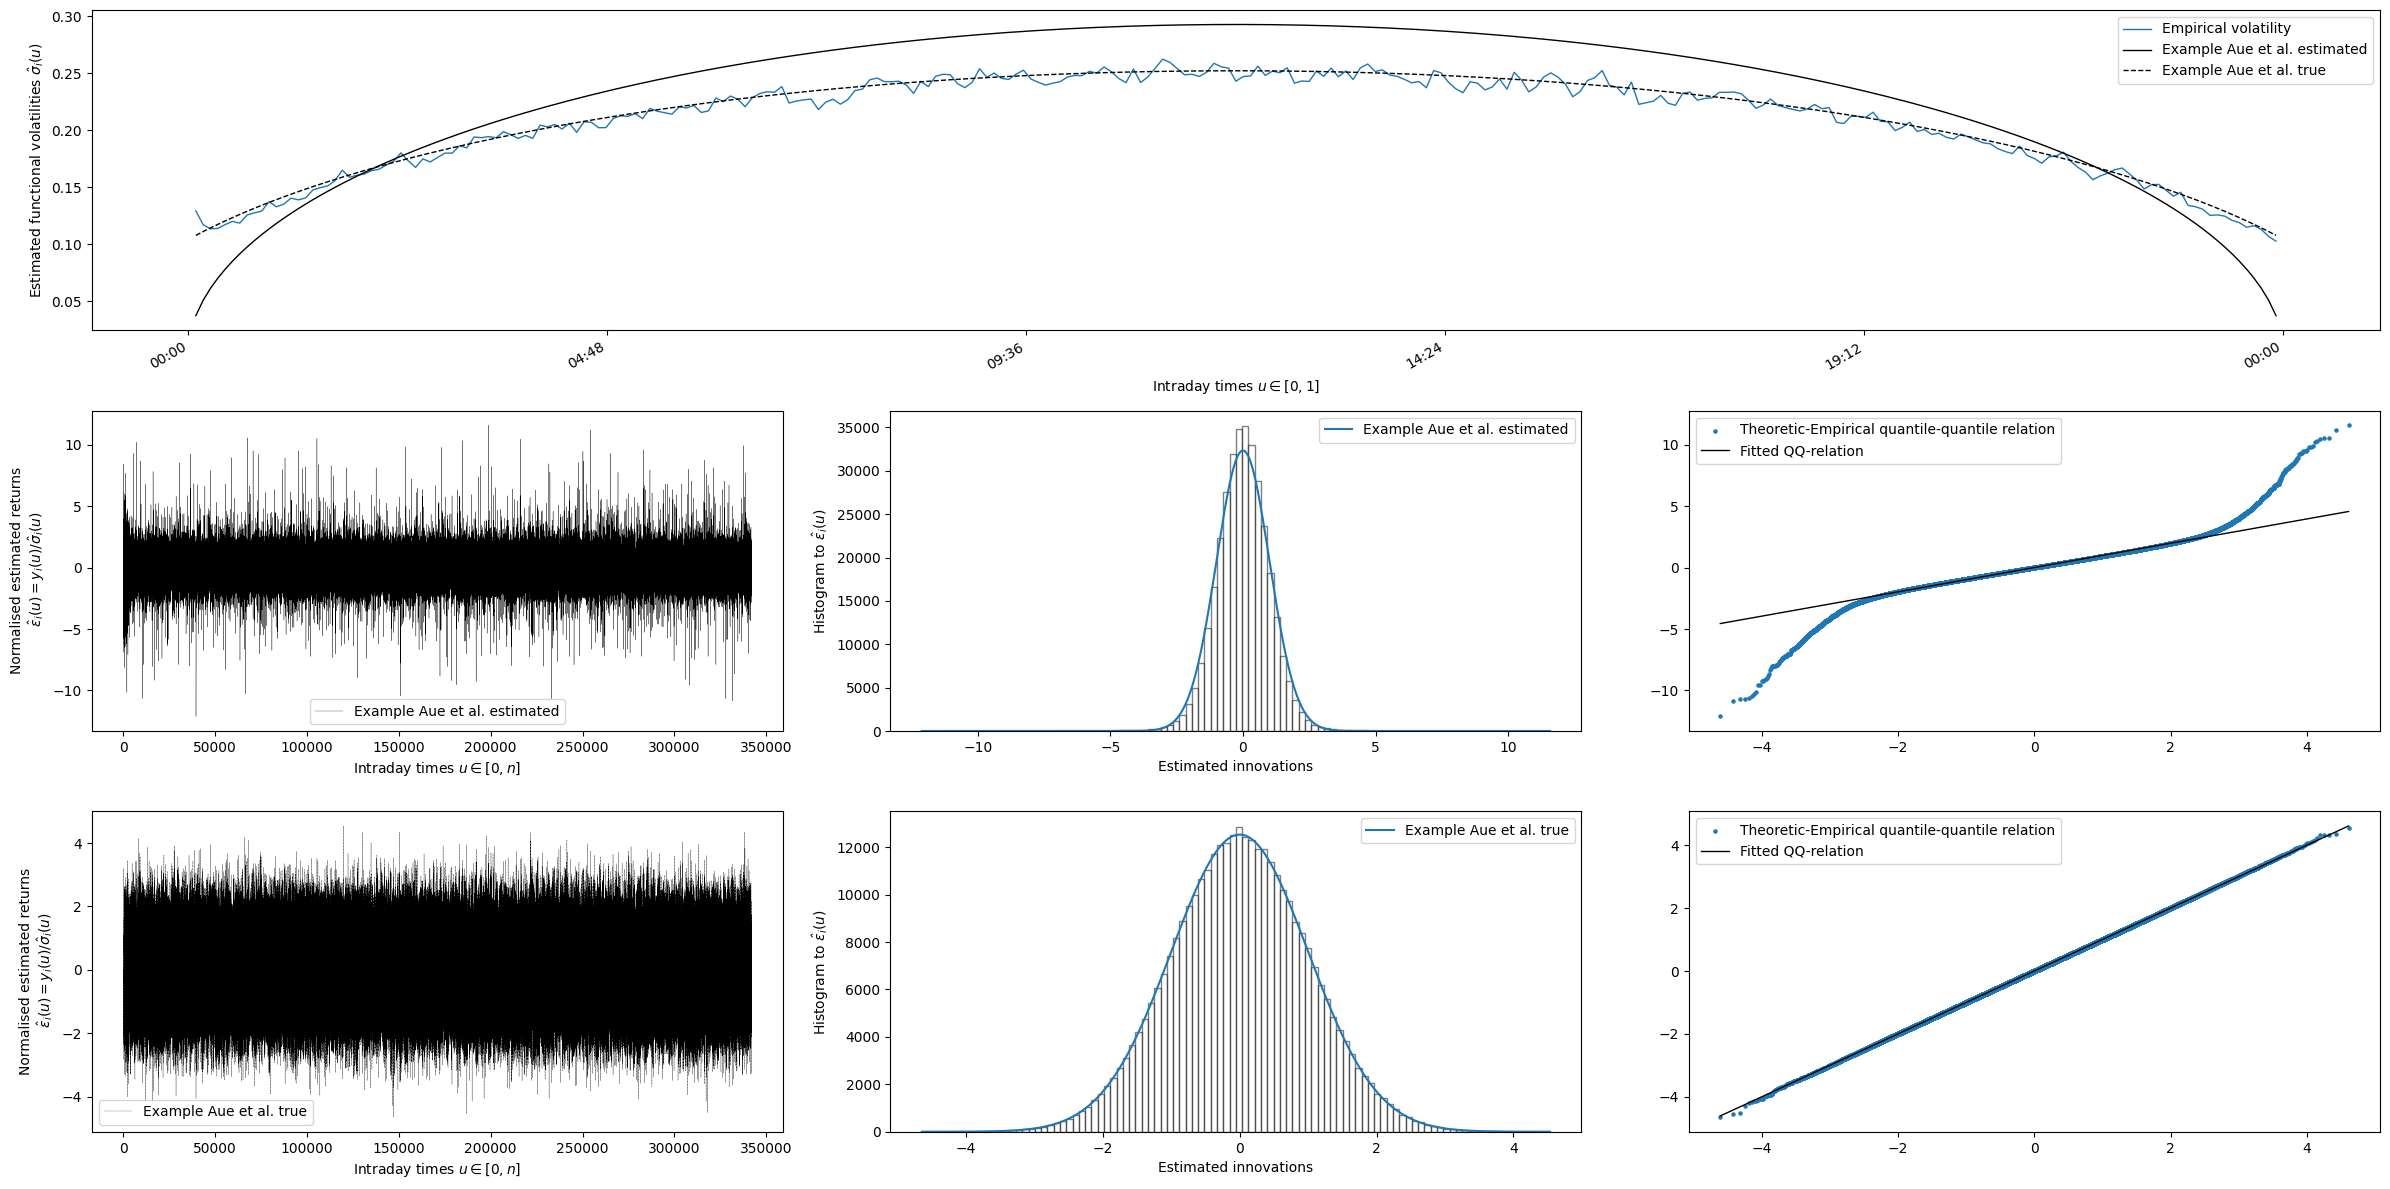

In [46]:
GenGraph(mY, [(mSigma_hatAEU, 'Example Aue et al. estimated'), (vsigma2M, 'Example Aue et al. true')], 
         time_index = np.linspace(1 / grid_length, 1 - (1 / grid_length), grid_length),
         date_index = np.linspace(1 / mY.shape[1], 1 - (1 / mY.shape[1]), mY.shape[1]),
         complete_index = np.arange(0, mY.shape[1] * mY.shape[0])
         )

In [ ]:
plt.plot(np.linspace(0,1, 285), np.sqrt(np.mean((mY) ** 2, axis = 1)))
plt.plot(np.linspace(0,1, 285), np.mean(mSigma_hatAEU, axis = 1) ** .5, label = 'est')
plt.plot(np.linspace(0,1, 285), np.mean(vsigma2M, axis = 1) ** .5, label = 'true')
plt.legend()
plt.show()